In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [4]:
data1 = pd.read_csv("data/exp1_little_cpu_20260116_120131.csv", header=1)
data2 = pd.read_csv("data/exp2_big_cpu_20260116_121717.csv", header=1)
data3 = pd.read_csv("data/exp3_gpu_grid_20260117_194828.csv", header=1)
data4 = pd.read_csv("data/exp4_partition_points_20260117_171535.csv", header=1).copy()
data5 = pd.read_csv("data/exp5_orders_20260117_185500.csv", header=1).copy()

def add_efficiency_cols(df):
    df = df.copy()
    df["fps_per_watt"] = df["fps"] / df["watts"]                         # efficiency
    df["energy_per_inf_J"] = df["watts"] * (df["latency"] / 1000.0)      # W * seconds = Joules
    return df

data1e = add_efficiency_cols(data1)
data2e = add_efficiency_cols(data2)
data3e = add_efficiency_cols(data3)
data4e = add_efficiency_cols(data4)
data5e = add_efficiency_cols(data5)


           2
4.827e-14 x + 2.292e-07 x + 1.855


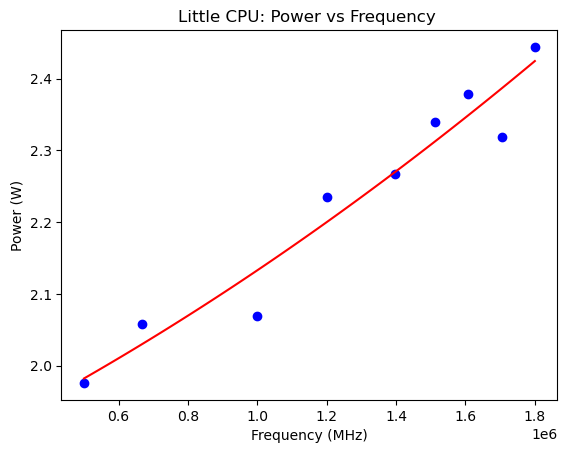

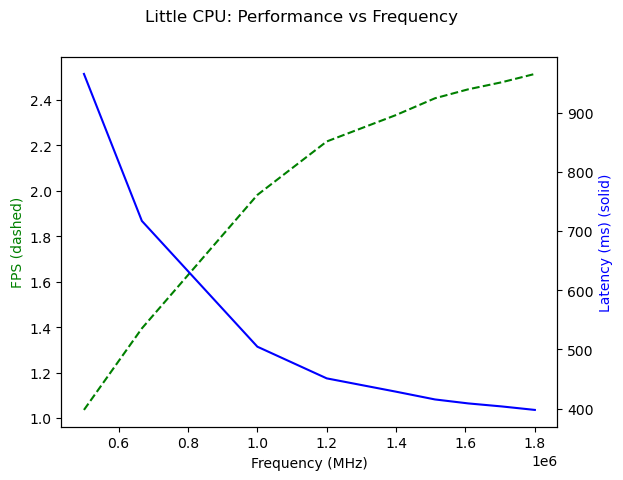

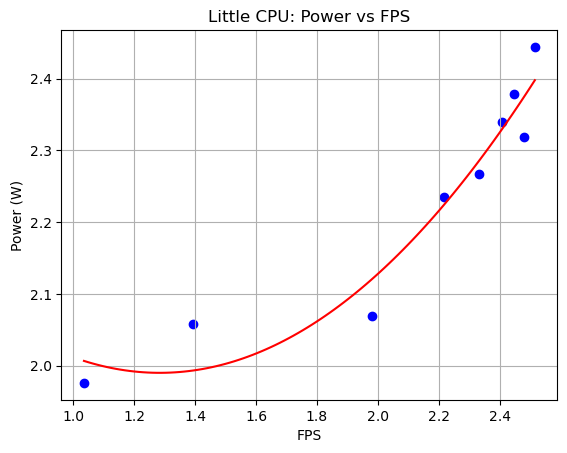

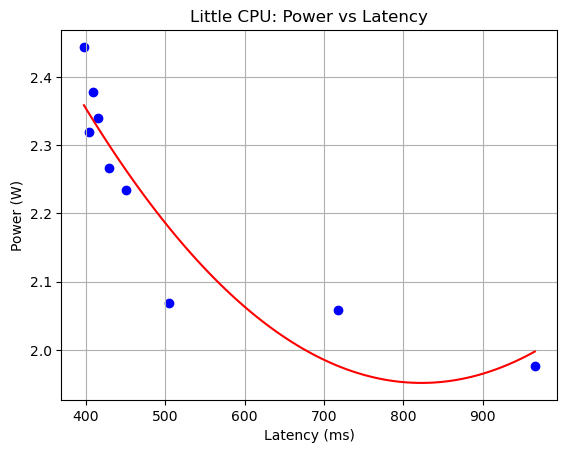

In [34]:
# EXPERIMENT 1


def calc_best_fit_parabula(x, y):
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)

    print(p)

    xs = np.linspace(min(x), max(x), 100)
    ys = p(xs)

    return xs, ys

def plot_with_best_fit(x, y, xlabel, ylabel, title):
    # Scatter measured data
    plt.scatter(x, y, color="b", label="Measured data")

    # Quadratic best-fit
    z = np.polyfit(x, y, 2)
    p = np.poly1d(z)
    xs = np.linspace(min(x), max(x), 100)
    plt.plot(xs, p(xs), "r-", label="Best fit")

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True)
    plt.show()


# Freq vs Power

xs_little, ys_little = calc_best_fit_parabula(data1["little_freq"], data1["watts"])

plt.plot(data1["little_freq"], data1["watts"], "o", color="b", label="Data")
plt.plot(xs_little, ys_little, "-", color="r", label="Best fit")
plt.title("Little CPU: Power vs Frequency ")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (W)")

plt.show()


# Freq vs Performance

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(data1["little_freq"], data1["fps"], "--", color="g")
ax2.plot(data1["little_freq"], data1["latency"], "-", color="b")

fig.suptitle("Little CPU: Performance vs Frequency")
ax1.set_xlabel("Frequency (MHz)")
ax1.set_ylabel("FPS (dashed)", color="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")

plt.show()

'''
# Power vs Performance

d = data1.sort_values("watts")

x = d["watts"].values
fps = d["fps"].values
lat = d["latency"].values

# Best fits
x_fps, fps_fit = calc_best_fit_parabula(x, fps)
x_lat, lat_fit = calc_best_fit_parabula(x, lat)

fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

# ---- FPS: points + fit (left axis) ----
ax1.plot(x, fps, "o", label="FPS data", color = "g")                 # points
ax1.plot(x_fps, fps_fit, "--", label="FPS best fit", color="g")    # fit

# ---- Latency: points + fit (right axis) ----
ax2.plot(x, lat, "s", label="Latency data", color="b")             # points
ax2.plot(x_lat, lat_fit, "-", label="Latency best fit", color="b") # fit

fig.suptitle("Little CPU: Power vs Performance")
ax1.set_xlabel("Power (W)")
ax1.set_ylabel("FPS (dashed)", color ="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")
ax1.grid(True)
plt.tight_layout()
plt.show()
'''


# Power vs FPS
plot_with_best_fit(
    data1["fps"],
    data1["watts"],
    xlabel="FPS",
    ylabel="Power (W)",
    title="Little CPU: Power vs FPS"
)

# Power vs Latency
plot_with_best_fit(
    data1["latency"],
    data1["watts"],
    xlabel="Latency (ms)",
    ylabel="Power (W)",
    title="Little CPU: Power vs Latency"
)

           2
6.998e-13 x - 7.705e-07 x + 2.523


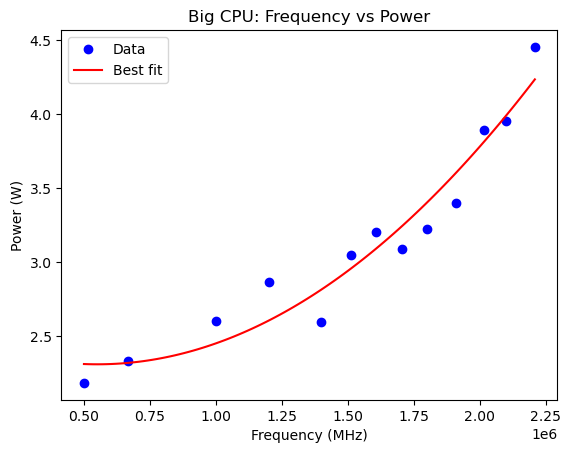

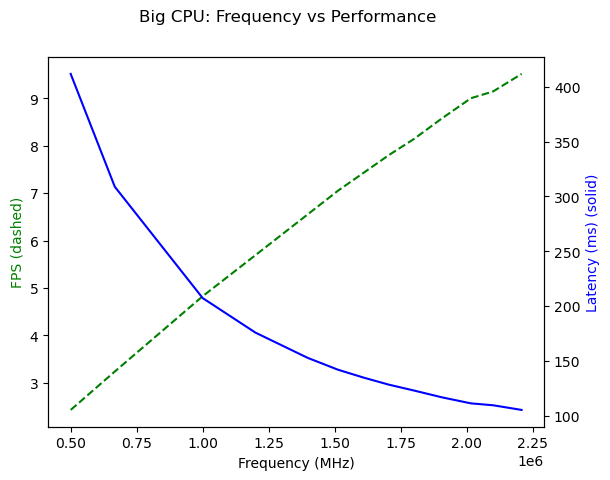

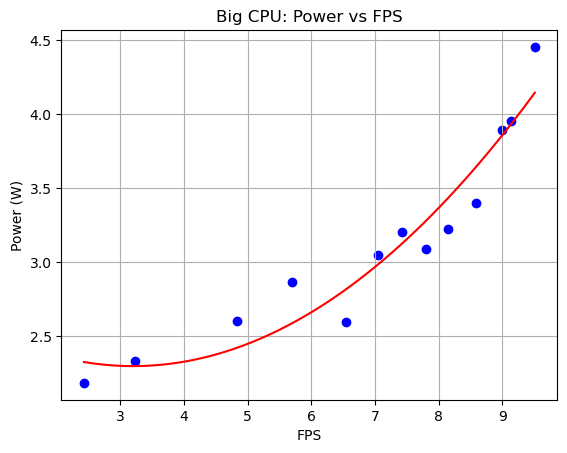

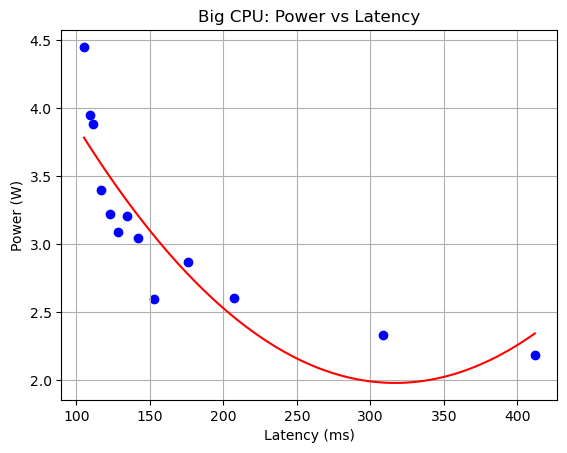

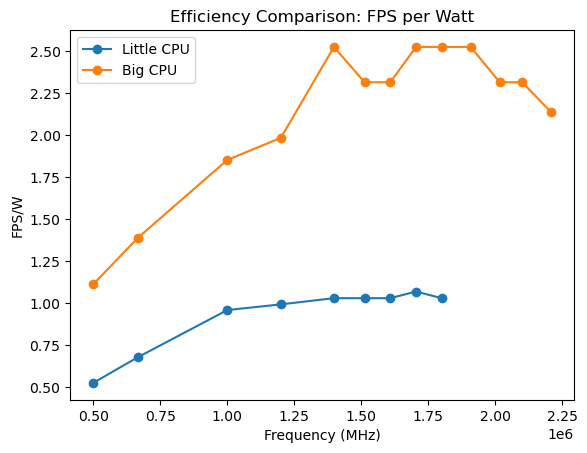

In [36]:
# EXP 2

xs_big, ys_big = calc_best_fit_parabula(data2["big_freq"], data2["watts"])
plt.plot(data2["big_freq"], data2["watts"], "o", color="b", label="Data")
plt.plot(xs_big, ys_big, "r-", label="Best fit")
plt.title("Big CPU: Frequency vs Power")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Power (W)")
plt.legend()
plt.show()



fig, ax1 = plt.subplots()

ax2 = ax1.twinx()
ax1.plot(data2["big_freq"], data2["fps"], "--", color="g")
ax2.plot(data2["big_freq"], data2["latency"], "-", color="b")

fig.suptitle("Big CPU: Frequency vs Performance")
ax1.set_xlabel("Frequency (MHz)")
ax1.set_ylabel("FPS (dashed)", color="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")

plt.show()


# Power vs Performance

d = data2.sort_values("watts")

x = d["watts"].values
fps = d["fps"].values
lat = d["latency"].values

'''
# Best fits
x_fps, fps_fit = calc_best_fit_parabula(x, fps)
x_lat, lat_fit = calc_best_fit_parabula(x, lat)

fig, ax1 = plt.subplots(figsize=(7, 5))
ax2 = ax1.twinx()

# ---- FPS: points + fit (left axis) ----
ax1.plot(x, fps, "o", label="FPS data", color = "g")                 # points
ax1.plot(x_fps, fps_fit, "--", label="FPS best fit", color="g")    # fit

# ---- Latency: points + fit (right axis) ----
ax2.plot(x, lat, "s", label="Latency data", color="b")             # points
ax2.plot(x_lat, lat_fit, "-", label="Latency best fit", color="b") # fit

fig.suptitle("Little CPU: Power vs Performance")
ax1.set_xlabel("Power (W)")
ax1.set_ylabel("FPS (dashed)", color ="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")
ax1.grid(True)
plt.tight_layout()
plt.show()
'''

# Power vs FPS
plot_with_best_fit(
    data2["fps"],
    data2["watts"],
    xlabel="FPS",
    ylabel="Power (W)",
    title="Big CPU: Power vs FPS"
)

# Power vs Latency
plot_with_best_fit(
    data2["latency"],
    data2["watts"],
    xlabel="Latency (ms)",
    ylabel="Power (W)",
    title="Big CPU: Power vs Latency"
)


plt.figure(figsize=(6.5, 4.8))
plt.plot(data1e["little_freq"], data1e["fps_per_watt"], "o-", label="Little CPU")
plt.plot(data2e["big_freq"], data2e["fps_per_watt"], "o-", label="Big CPU")
plt.title("Efficiency Comparison: FPS per Watt")
plt.xlabel("Frequency (MHz)")
plt.ylabel("FPS/W")
plt.legend()
plt.show()

Best fit plane: watts = 2.382e-07 * big_freq + 8.388e-08 * little_freq + 2.638


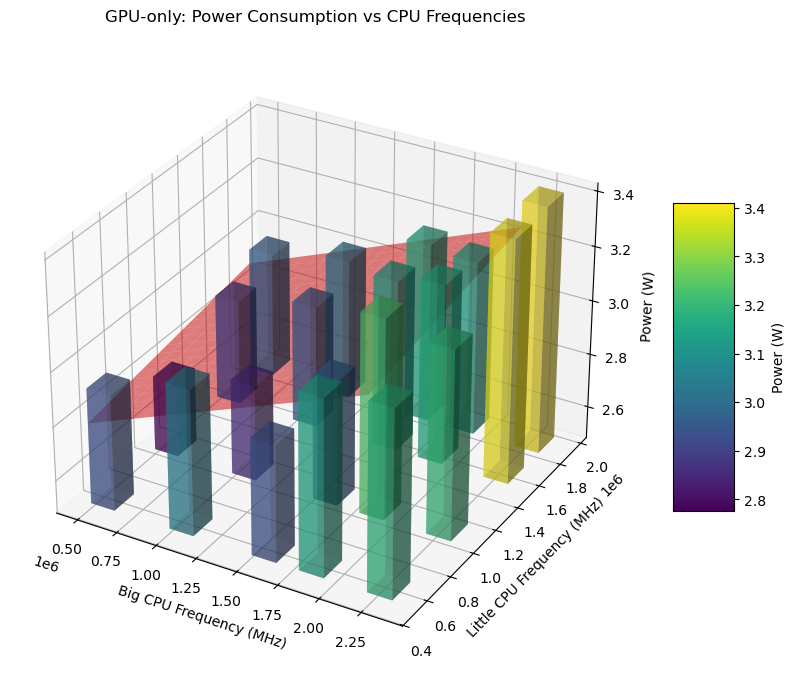

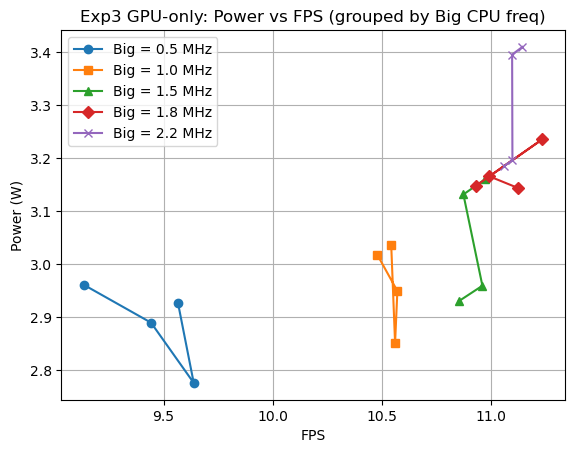

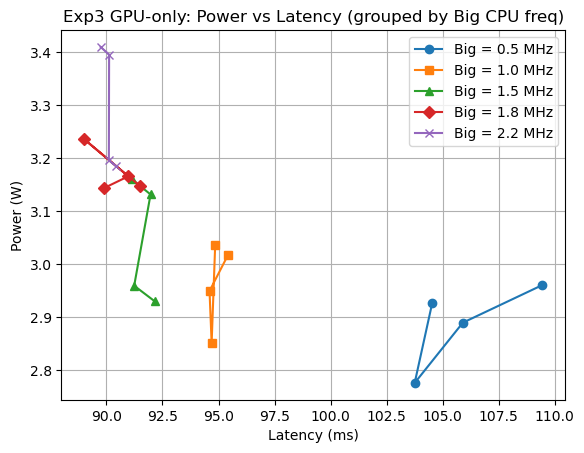

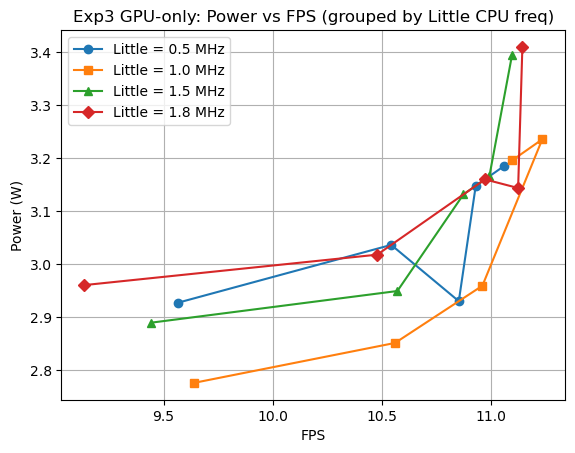

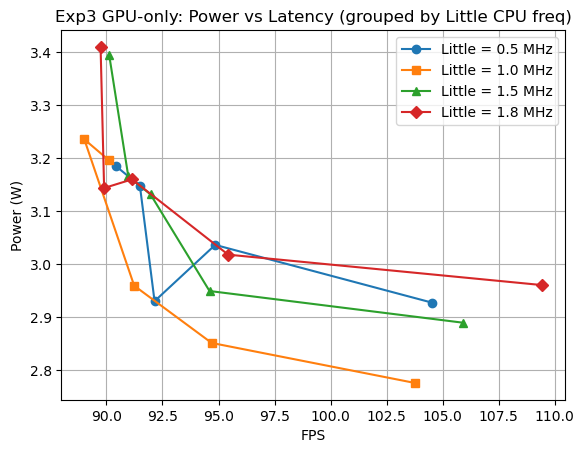

In [37]:
# EXPERIMENT 3


# Create 3D histogram
from mpl_toolkits.mplot3d import Axes3D

# Get data
big_freqs = data3["big_freq"].values
little_freqs = data3["little_freq"].values
watts = data3["watts"].values

# Fit a 2D plane: z = a*x + b*y + c
# Create design matrix A = [x, y, 1]
A = np.column_stack([big_freqs, little_freqs, np.ones_like(watts)])
# Solve least squares: A * [a, b, c]^T = watts
coeffs, _, _, _ = np.linalg.lstsq(A, watts, rcond=None)
a, b, c = coeffs

print(f"Best fit plane: watts = {a:.3e} * big_freq + {b:.3e} * little_freq + {c:.3f}")

# Create the 3D plot
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Calculate bar widths (thinner bars)
big_freq_unique = np.sort(np.unique(big_freqs))
little_freq_unique = np.sort(np.unique(little_freqs))
dx = (big_freq_unique[1] - big_freq_unique[0]) * 0.3 if len(big_freq_unique) > 1 else 50000
dy = (little_freq_unique[1] - little_freq_unique[0]) * 0.3 if len(little_freq_unique) > 1 else 50000

# Create bars starting at z=2 with height = watts - 2
z_base = 2.5
dz = watts - z_base

# Create 3D bars
colors = plt.cm.viridis((watts - watts.min()) / (watts.max() - watts.min()))
ax.bar3d(big_freqs, little_freqs, np.full_like(watts, z_base), dx, dy, dz, color=colors, alpha=0.5)

# Add best fit plane
big_range = np.linspace(big_freqs.min(), big_freqs.max(), 20)
little_range = np.linspace(little_freqs.min(), little_freqs.max(), 20)
X_plane, Y_plane = np.meshgrid(big_range, little_range)
Z_plane = a * X_plane + b * Y_plane + c

ax.plot_surface(X_plane, Y_plane, Z_plane, alpha=0.5, color='red', edgecolor='none')

# Labels and title
ax.set_xlabel('Big CPU Frequency (MHz)', fontsize=10)
ax.set_ylabel('Little CPU Frequency (MHz)', fontsize=10)
ax.set_zlabel('Power (W)', fontsize=10)
ax.set_title('GPU-only: Power Consumption vs CPU Frequencies ', fontsize=12, pad=20)

# Add colorbar
mappable = plt.cm.ScalarMappable(cmap='viridis')
mappable.set_array(watts)
fig.colorbar(mappable, ax=ax, shrink=0.5, aspect=5, label='Power (W)')

plt.show()


# Power vs FPS (grouped by big_freq)
markers = ["o", "s", "^", "D", "x", "*"]

plt.figure(figsize=(6.5, 4.8))

for (bf, g), m in zip(data3.groupby("big_freq"), markers):
    g = g.sort_values("little_freq")
    plt.plot(
        g["fps"],
        g["watts"],
        linestyle="-",
        marker=m,
        markersize=6,
        label=f"Big = {bf/1e6:.1f} MHz"
    )

plt.title("Exp3 GPU-only: Power vs FPS (grouped by Big CPU freq)")
plt.xlabel("FPS")
plt.ylabel("Power (W)")
plt.legend()
plt.grid(True)

plt.show()


# Power vs Latency (grouped by big_freq)
plt.figure(figsize=(6.5, 4.8))

for (bf, g), m in zip(data3.groupby("big_freq"), markers):
    g = g.sort_values("little_freq")
    plt.plot(
        g["latency"],
        g["watts"],
        linestyle="-",
        marker=m,
        markersize=6,
        label=f"Big = {bf/1e6:.1f} MHz"
    )

plt.title("Exp3 GPU-only: Power vs Latency (grouped by Big CPU freq)")
plt.xlabel("Latency (ms)")
plt.ylabel("Power (W)")
plt.legend()
plt.grid(True)

plt.show()


# Power vs FPS grouped by little_freq
markers = ["o", "s", "^", "D", "x", "*"]

plt.figure(figsize=(6.5, 4.8))

for (lf, g), m in zip(data3.groupby("little_freq"), markers):
    g = g.sort_values("big_freq")
    plt.plot(
        g["fps"],
        g["watts"],
        linestyle="-",
        marker=m,
        markersize=6,
        label=f"Little = {lf/1e6:.1f} MHz"
    )

plt.title("Exp3 GPU-only: Power vs FPS (grouped by Little CPU freq)")
plt.xlabel("FPS")
plt.ylabel("Power (W)")
plt.legend()
plt.grid(True)

plt.show()



# Power vs Latency grouped by little_freq
markers = ["o", "s", "^", "D", "x", "*"]

plt.figure(figsize=(6.5, 4.8))

for (lf, g), m in zip(data3.groupby("little_freq"), markers):
    g = g.sort_values("big_freq")
    plt.plot(
        g["latency"],
        g["watts"],
        linestyle="-",
        marker=m,
        markersize=6,
        label=f"Little = {lf/1e6:.1f} MHz"
    )

plt.title("Exp3 GPU-only: Power vs Latency (grouped by Little CPU freq)")
plt.xlabel("FPS")
plt.ylabel("Power (W)")
plt.legend()
plt.grid(True)

plt.show()




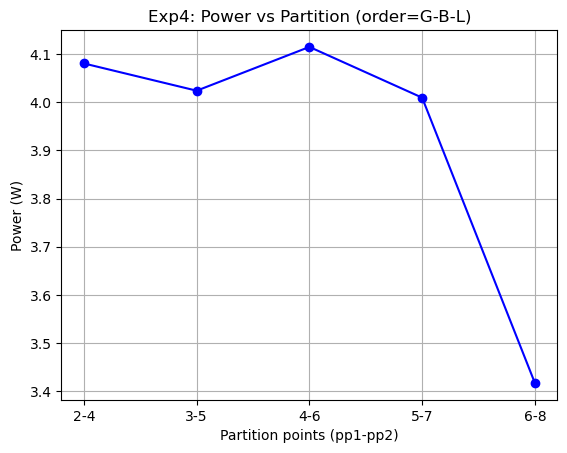

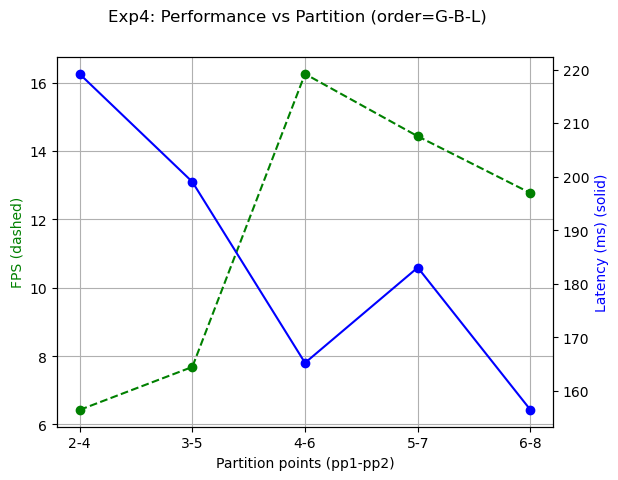

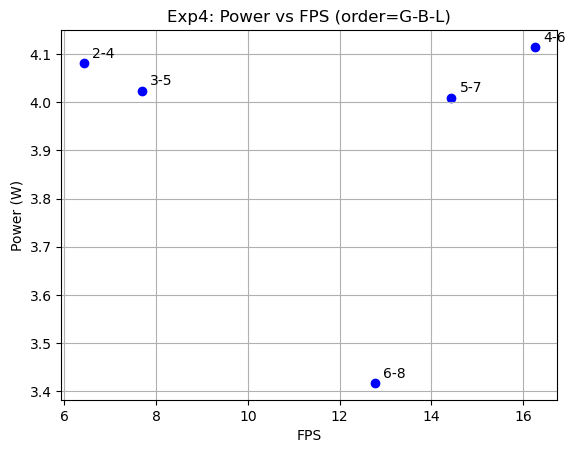

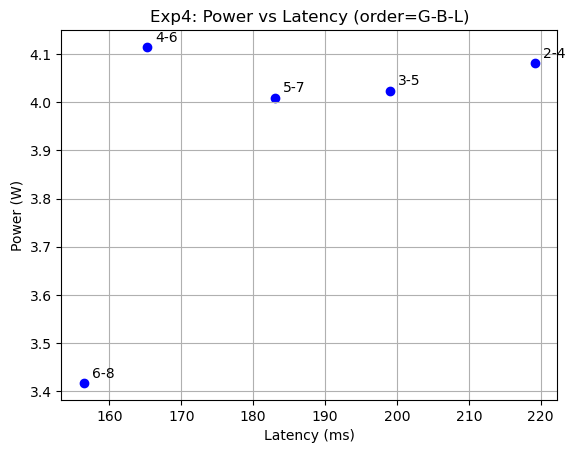

In [40]:
# EXPERIMENT 4


# Create missing fields (this fixes your error)
data4["pp_index"] = data4["pp1"] * 10 + data4["pp2"]              # numeric ordering key
data4["pp_label"] = data4["pp1"].astype(str) + "-" + data4["pp2"].astype(str)

# Sort by partition configuration
data4 = data4.sort_values("pp_index")

order_name = data4["order"].iloc[0]

# ==========================================================
# Graph 1: Partition points vs Power (with readable labels)
# ==========================================================
plt.figure()
plt.plot(data4["pp_index"], data4["watts"], "o-", color="b")
plt.title(f"Exp4: Power vs Partition (order={order_name})")
plt.xlabel("Partition points (pp1-pp2)")
plt.ylabel("Power (W)")
plt.xticks(data4["pp_index"], data4["pp_label"])
plt.grid(True)
plt.show()

# ==========================================================
# Graph 2: Partition points vs Performance (FPS + latency)
# ==========================================================
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(data4["pp_index"], data4["fps"], "--", color="g", marker="o")
ax2.plot(data4["pp_index"], data4["latency"], "-", color="b", marker="o")

fig.suptitle(f"Exp4: Performance vs Partition (order={order_name})")
ax1.set_xlabel("Partition points (pp1-pp2)")
ax1.set_ylabel("FPS (dashed)", color="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")
ax1.grid(True)

ax1.set_xticks(data4["pp_index"])
ax1.set_xticklabels(data4["pp_label"])

plt.show()

# ==========================================================
# Graph 3: Power vs FPS (annotated by partition points)
# ==========================================================
plt.figure()
plt.scatter(data4["fps"], data4["watts"], color="b")
for _, r in data4.iterrows():
    plt.annotate(r["pp_label"], (r["fps"], r["watts"]),
                 textcoords="offset points", xytext=(6,4))
plt.title(f"Exp4: Power vs FPS (order={order_name})")
plt.xlabel("FPS")
plt.ylabel("Power (W)")
plt.grid(True)
plt.show()

# ==========================================================
# Graph 4: Power vs Latency (annotated by partition points)
# ==========================================================
plt.figure()
plt.scatter(data4["latency"], data4["watts"], color="b")
for _, r in data4.iterrows():
    plt.annotate(r["pp_label"], (r["latency"], r["watts"]),
                 textcoords="offset points", xytext=(6,4))
plt.title(f"Exp4: Power vs Latency (order={order_name})")
plt.xlabel("Latency (ms)")
plt.ylabel("Power (W)")
plt.grid(True)
plt.show()


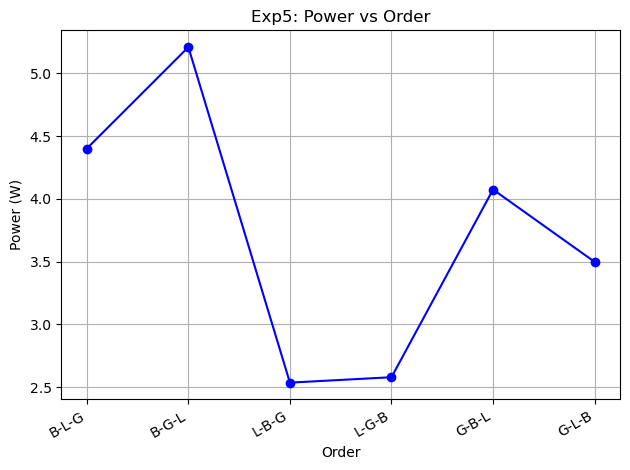

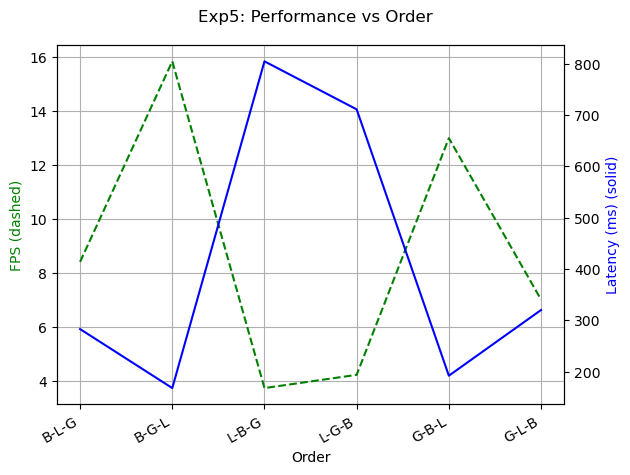

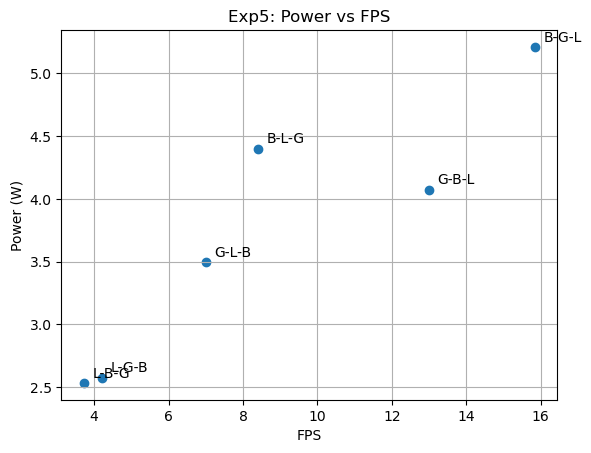

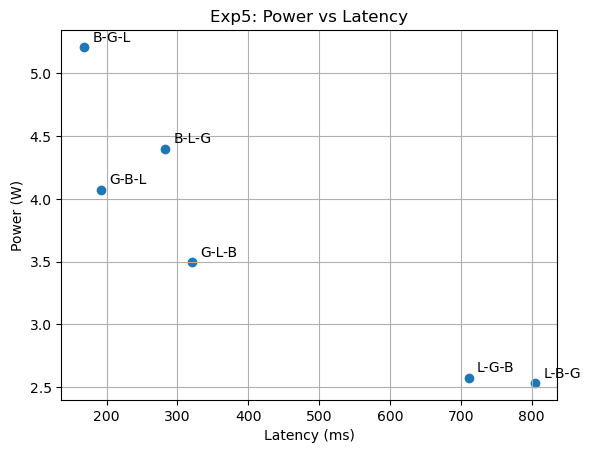

In [41]:
# EXPERIMENT 5

data5 = pd.read_csv("data/exp5_orders_20260117_185500.csv", header=1).copy()

# Keep the existing row order from the CSV as the x-axis order.
orders = list(data5["order"].values)
x = np.arange(len(orders))

# ---- Plot 5A: Order vs Power ----
plt.plot(x, data5["watts"], "o-", color="b")
plt.title("Exp5: Power vs Order")
plt.xlabel("Order")
plt.ylabel("Power (W)")
plt.xticks(x, orders, rotation=30, ha="right")
plt.grid(True)
plt.tight_layout()
plt.show()

# ---- Plot 5B: Order vs Performance (twin axis) ----
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()

ax1.plot(x, data5["fps"], "--", color="g")
ax2.plot(x, data5["latency"], "-", color="b")

fig.suptitle("Exp5: Performance vs Order")
ax1.set_xlabel("Order")
ax1.set_ylabel("FPS (dashed)", color="g")
ax2.set_ylabel("Latency (ms) (solid)", color="b")

ax1.set_xticks(x)
ax1.set_xticklabels(orders, rotation=30, ha="right")

ax1.grid(True)
plt.tight_layout()
plt.show()


# Power vs FPS (annotated by order)
plt.figure()
plt.scatter(data5["fps"], data5["watts"])
for _, r in data5.iterrows():
    plt.annotate(r["order"], (r["fps"], r["watts"]), textcoords="offset points", xytext=(6,4))
plt.title("Exp5: Power vs FPS")
plt.xlabel("FPS")
plt.ylabel("Power (W)")
plt.grid(True)
plt.show()

# Power vs Latency (annotated by order)
plt.figure()
plt.scatter(data5["latency"], data5["watts"])
for _, r in data5.iterrows():
    plt.annotate(r["order"], (r["latency"], r["watts"]), textcoords="offset points", xytext=(6,4))
plt.title("Exp5: Power vs Latency")
plt.xlabel("Latency (ms)")
plt.ylabel("Power (W)")
plt.grid(True)
plt.show()
